# 01. Exploratory Data Analysis
## IBM Telco Customer Churn

**Goal:** Understand the structure of the data, identify which customer segments churn most,
and surface actionable behavioral patterns that will inform both feature engineering and the
business narrative.

**Dataset:** IBM Telco Customer Churn — 7,043 customers, 33 features covering demographics,
services subscribed, contract details, billing, and churn outcomes.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

# ── Output directory ──────────────────────────────────────────────────────────
FIG_DIR = "../outputs/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("Imports complete.")


Imports complete.


---
## 1. Load & Inspect the Data


In [2]:
df = pd.read_excel("../data/Telco_customer_churn.xlsx")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
print("Column names:")
print(df.columns.tolist())


Shape: 7,043 rows x 33 columns

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [3]:
# Data types
print("Data types:")
print(df.dtypes)
print()

# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"Missing values: {len(missing)} column(s) with nulls")
if len(missing) > 0:
    print(missing)
else:
    print("No missing values found.")


Data types:
CustomerID               str
Count                  int64
Country                  str
State                    str
City                     str
Zip Code               int64
Lat Long                 str
Latitude             float64
Longitude            float64
Gender                   str
Senior Citizen           str
Partner                  str
Dependents               str
Tenure Months          int64
Phone Service            str
Multiple Lines           str
Internet Service         str
Online Security          str
Online Backup            str
Device Protection        str
Tech Support             str
Streaming TV             str
Streaming Movies         str
Contract                 str
Paperless Billing        str
Payment Method           str
Monthly Charges      float64
Total Charges         object
Churn Label              str
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason             str
dtype: object

Missing values: 

In [4]:
# Quick statistical summary for numeric columns
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.00,0.00,1.00,1.00,1.00,1.00,1.00
Zip Code,7043.0,93521.96,1865.79,90001.00,92102.00,93552.00,95351.00,96161.00
Latitude,7043.0,36.28,2.46,32.56,34.03,36.39,38.22,41.96
Longitude,7043.0,-119.80,2.16,-124.30,-121.82,-119.73,-118.04,-114.19
Tenure Months,7043.0,32.37,24.56,0.00,9.00,29.00,55.00,72.00
Monthly Charges,7043.0,64.76,30.09,18.25,35.50,70.35,89.85,118.75
Churn Value,7043.0,0.27,0.44,0.00,0.00,0.00,1.00,1.00
Churn Score,7043.0,58.70,21.53,5.00,40.00,61.00,75.00,100.00
CLTV,7043.0,4400.30,1183.06,2003.00,3469.00,4527.00,5380.50,6500.00


### 1.1 Drop Non-Analytical Columns

`Count`, `Lat Long`, `Latitude`, `Longitude`, `Zip Code`, `City`, `State`, `Country`
are geographic identifiers with no predictive signal for modeling.
We drop them here to keep the analysis focused.


In [5]:
drop_cols = ["Count", "Lat Long", "Latitude", "Longitude",
             "Zip Code", "City", "State", "Country"]
df.drop(columns=drop_cols, inplace=True)
print(f"Working shape after dropping geo columns: {df.shape}")


Working shape after dropping geo columns: (7043, 25)


In [6]:
# Force numeric columns to correct dtype.
# Raw Excel has blank strings " " in Total Charges for zero-tenure customers.
# This silently poisons any cell that calls .corr(), .mean(), or .describe().
NUMERIC_COLS = ["Tenure Months", "Monthly Charges", "Total Charges",
                "Churn Score", "CLTV", "Churn Value"]
df[NUMERIC_COLS] = df[NUMERIC_COLS].apply(pd.to_numeric, errors="coerce")

# Confirm dtypes are now float/int
print(df[NUMERIC_COLS].dtypes)
print("\nNull counts after coercion:")
print(df[NUMERIC_COLS].isnull().sum())

Tenure Months        int64
Monthly Charges    float64
Total Charges      float64
Churn Score          int64
CLTV                 int64
Churn Value          int64
dtype: object

Null counts after coercion:
Tenure Months       0
Monthly Charges     0
Total Charges      11
Churn Score         0
CLTV                0
Churn Value         0
dtype: int64


---
## 2. Overall Churn Rate: Is the Target Imbalanced?

Before any segmentation, we need to know the baseline churn rate.
A heavily imbalanced target changes every modeling decision downstream,
from evaluation metrics to resampling strategy.


Churn rate: 26.5%
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


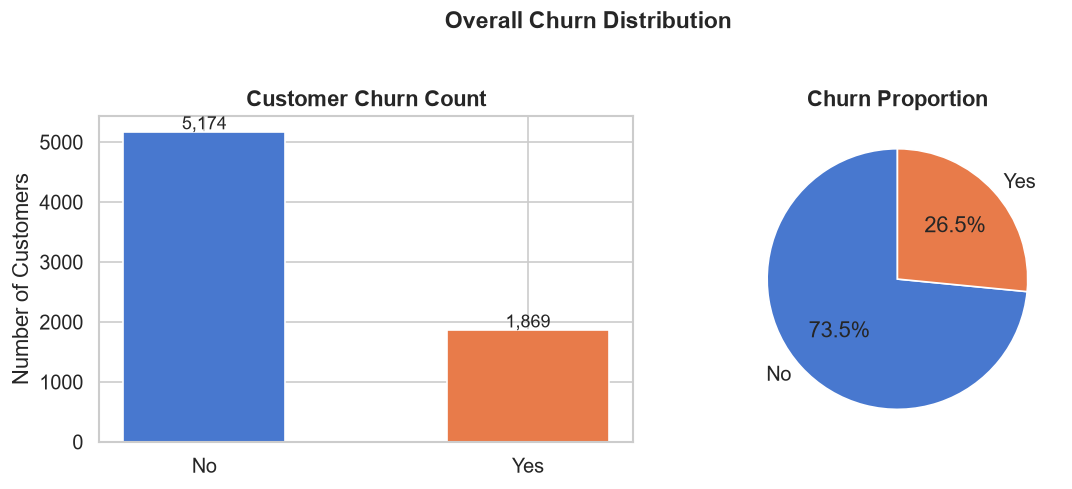

In [7]:
churn_counts = df["Churn Label"].value_counts()
churn_rate   = df["Churn Value"].mean() * 100

print(f"Churn rate: {churn_rate:.1f}%")
print(churn_counts)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
colors = ["#4878CF", "#E87B4A"]
axes[0].bar(churn_counts.index, churn_counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_title("Customer Churn Count", fontweight="bold")
axes[0].set_ylabel("Number of Customers")
for bar, val in zip(axes[0].patches, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f"{val:,}", ha="center", fontsize=11)

# Pie chart
axes[1].pie(churn_counts.values, labels=churn_counts.index,
            autopct="%1.1f%%", colors=colors, startangle=90,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Churn Proportion", fontweight="bold")

plt.suptitle("Overall Churn Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_churn_distribution.png")
plt.show()


**Finding:** The churn rate is approximately **26.5%**. This is a moderately imbalanced dataset.
Accuracy is a misleading metric here. A model that predicts "No Churn" for every customer would
achieve ~73.5% accuracy while being completely useless. We will use **ROC-AUC**,
**precision-recall curve**, and **F1-score** as primary evaluation metrics.


---
## 3. Which Segments Churn Most?

### 3.1 Contract Type

Contract type is one of the most actionable levers a business has.
Customers on month-to-month contracts face zero switching cost. Longer contracts
create commitment. The key question: how different is the churn rate across contract types?


         Contract  Churn Rate  Customers  Churn Rate %
0  Month-to-month    0.427097       3875          42.7
1        One year    0.112695       1473          11.3
2        Two year    0.028319       1695           2.8


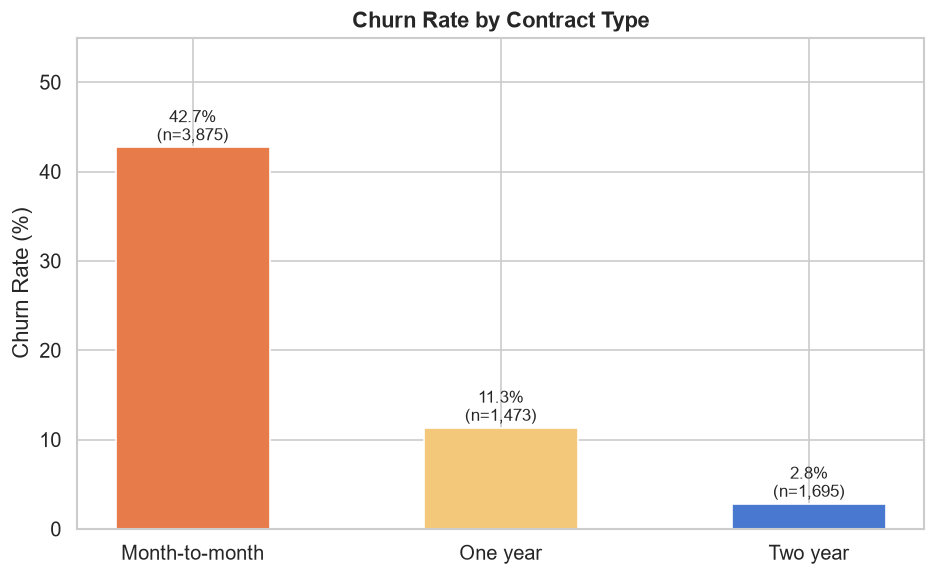

In [8]:
contract_churn = (df.groupby("Contract")["Churn Value"]
                  .agg(["mean", "count"])
                  .rename(columns={"mean": "Churn Rate", "count": "Customers"})
                  .sort_values("Churn Rate", ascending=False)
                  .reset_index())
contract_churn["Churn Rate %"] = (contract_churn["Churn Rate"] * 100).round(1)

print(contract_churn)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(contract_churn["Contract"], contract_churn["Churn Rate %"],
              color=["#E87B4A", "#F4C87A", "#4878CF"], edgecolor="white", width=0.5)
ax.set_title("Churn Rate by Contract Type", fontweight="bold", fontsize=13)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 55)
for bar, row in zip(bars, contract_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{row._4}%\n(n={row.Customers:,})", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_churn_by_contract.png")
plt.show()


**Finding:** Month-to-month customers churn at roughly **42%**, compared to **11%** for
one-year and under **3%** for two-year contract customers. This is the single strongest
structural predictor in the dataset. The business implication is direct: every month-to-month
customer is a retention risk. Incentivizing contract upgrades is the highest-leverage intervention.


### 3.2 Tenure

New customers are often the most volatile. They have not yet embedded the service into
their daily routine, and they are still evaluating alternatives. Tenure bucketing reveals
whether churn is concentrated in the early lifecycle.


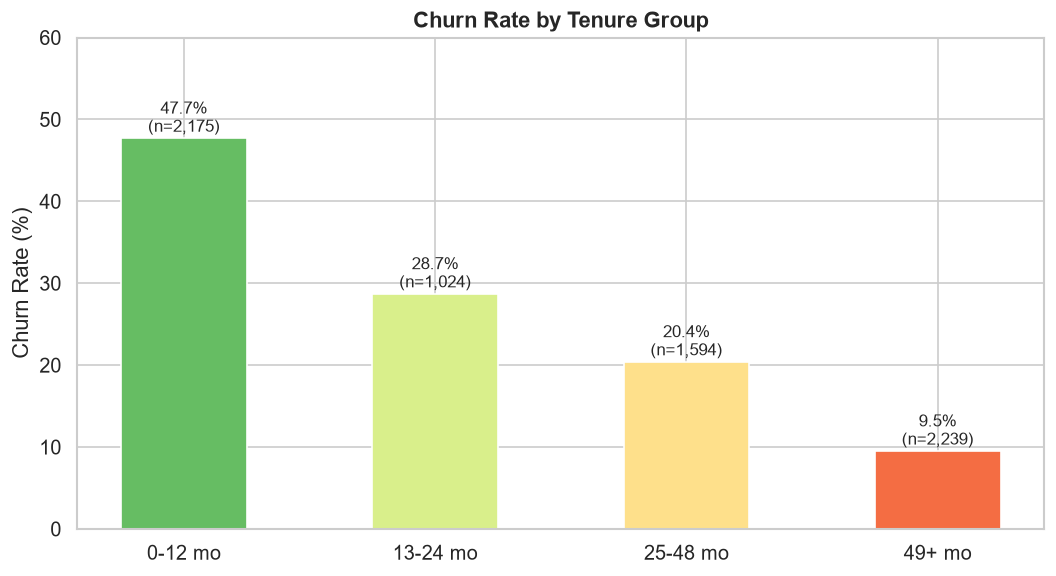

In [9]:
bins   = [0, 12, 24, 48, df["Tenure Months"].max()]
labels = ["0-12 mo", "13-24 mo", "25-48 mo", "49+ mo"]
df["Tenure Group"] = pd.cut(df["Tenure Months"], bins=bins, labels=labels, right=True)

tenure_churn = (df.groupby("Tenure Group", observed=True)["Churn Value"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "Churn Rate", "count": "Customers"})
                .reset_index())
tenure_churn["Churn Rate %"] = (tenure_churn["Churn Rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("RdYlGn_r", len(tenure_churn))
bars = ax.bar(tenure_churn["Tenure Group"].astype(str), tenure_churn["Churn Rate %"],
              color=palette, edgecolor="white", width=0.5)
ax.set_title("Churn Rate by Tenure Group", fontweight="bold", fontsize=13)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 60)
for bar, row in zip(bars, tenure_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{row._4}%\n(n={row.Customers:,})", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_churn_by_tenure.png")
plt.show()


**Finding:** Churn is sharply concentrated in the first 12 months, with rates near **50%** in
the 0-12 month cohort, dropping steeply thereafter. Customers who survive past 24 months are
substantially more stable. This points to onboarding experience and early-tenure engagement as
critical retention windows. A targeted intervention in months 1-6 would have disproportionate
business impact.


### 3.3 Payment Method

Payment method is a proxy for customer engagement and financial friction.
Electronic check payments lack the automatic commitment of bank transfers or card auto-pay,
which may reflect lower service stickiness overall.


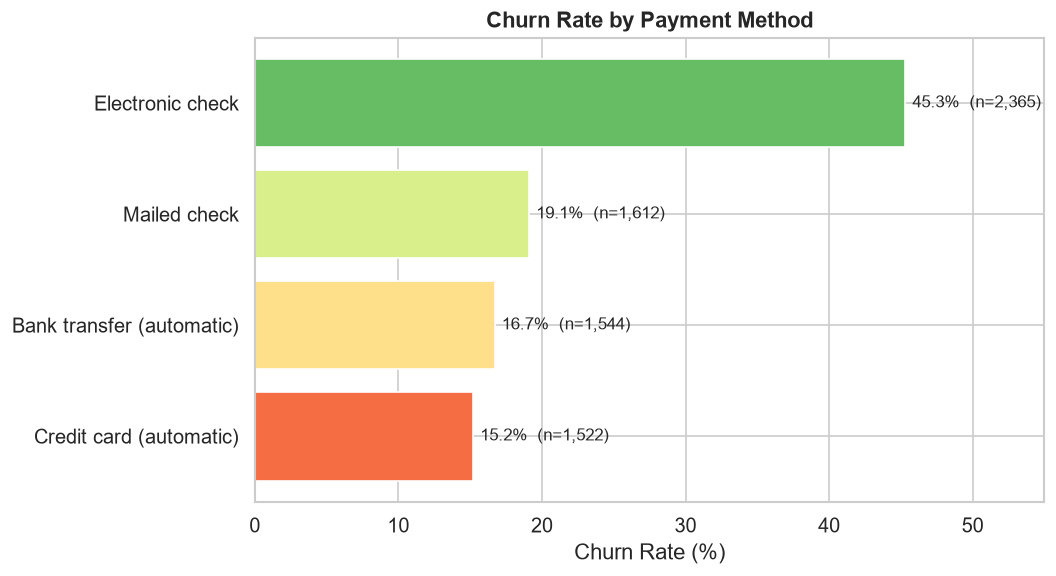

In [10]:
pay_churn = (df.groupby("Payment Method")["Churn Value"]
             .agg(["mean", "count"])
             .rename(columns={"mean": "Churn Rate", "count": "Customers"})
             .sort_values("Churn Rate", ascending=True)
             .reset_index())
pay_churn["Churn Rate %"] = (pay_churn["Churn Rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
palette = sns.color_palette("RdYlGn", len(pay_churn))
bars = ax.barh(pay_churn["Payment Method"], pay_churn["Churn Rate %"],
               color=palette, edgecolor="white")
ax.set_title("Churn Rate by Payment Method", fontweight="bold", fontsize=13)
ax.set_xlabel("Churn Rate (%)")
ax.set_xlim(0, 55)
for bar, row in zip(bars, pay_churn.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{row._4}%  (n={row.Customers:,})", va="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_churn_by_payment.png")
plt.show()


**Finding:** Electronic check users churn at roughly **45%**, more than double the rate of
customers on automatic bank transfer or credit card. This is partly a confound with contract type
(month-to-month customers are more likely to use electronic check), but the pattern is strong
enough to warrant inclusion as a feature. It also suggests a product intervention: nudging
electronic check users toward auto-pay enrollment may reduce churn independently of contract type.


### 3.4 Internet Service Type

Fiber optic is the premium tier. If fiber customers churn disproportionately,
it suggests a service quality or value-for-money problem at the top of the product line.


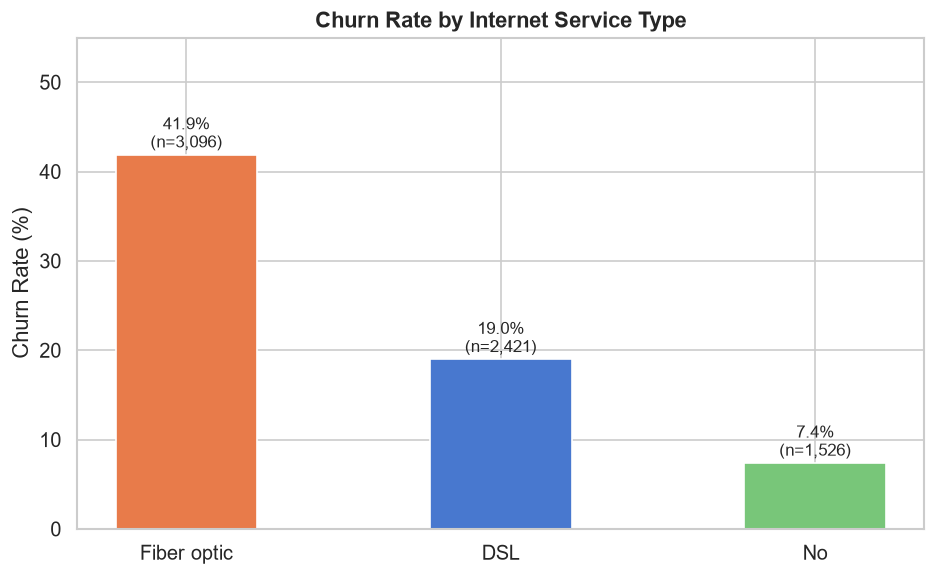

In [11]:
internet_churn = (df.groupby("Internet Service")["Churn Value"]
                  .agg(["mean", "count"])
                  .rename(columns={"mean": "Churn Rate", "count": "Customers"})
                  .sort_values("Churn Rate", ascending=False)
                  .reset_index())
internet_churn["Churn Rate %"] = (internet_churn["Churn Rate"] * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#E87B4A", "#4878CF", "#78C679"]
bars = ax.bar(internet_churn["Internet Service"], internet_churn["Churn Rate %"],
              color=colors, edgecolor="white", width=0.45)
ax.set_title("Churn Rate by Internet Service Type", fontweight="bold", fontsize=13)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 55)
for bar, row in zip(bars, internet_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{row._4}%\n(n={row.Customers:,})", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_churn_by_internet.png")
plt.show()


**Finding:** Fiber optic customers churn at approximately **42%**, compared to **19%** for
DSL and under **8%** for customers with no internet service. This is a red flag. Fiber is the
most expensive tier and likely the most competitive. It suggests that despite the premium product,
customer satisfaction or perceived value may be lower, possibly due to pricing relative to
competitors or unmet service quality expectations.


---
## 4. Compound Behavioral Pattern: The Highest-Risk Segment

Single-variable analysis tells part of the story. The real insight comes from combining
contract type, internet service, and payment method to identify the highest-risk compound segment.


In [12]:
# Month-to-month + Fiber Optic + Electronic Check
high_risk_mask = (
    (df["Contract"]        == "Month-to-month") &
    (df["Internet Service"]== "Fiber optic")    &
    (df["Payment Method"]  == "Electronic check")
)

high_risk_df   = df[high_risk_mask]
baseline_rate  = df["Churn Value"].mean() * 100
high_risk_rate = high_risk_df["Churn Value"].mean() * 100

print(f"High-risk segment size : {len(high_risk_df):,} customers")
print(f"High-risk churn rate   : {high_risk_rate:.1f}%")
print(f"Overall baseline rate  : {baseline_rate:.1f}%")
print(f"Relative uplift        : {high_risk_rate / baseline_rate:.1f}x the baseline")


High-risk segment size : 1,307 customers
High-risk churn rate   : 60.4%
Overall baseline rate  : 26.5%
Relative uplift        : 2.3x the baseline


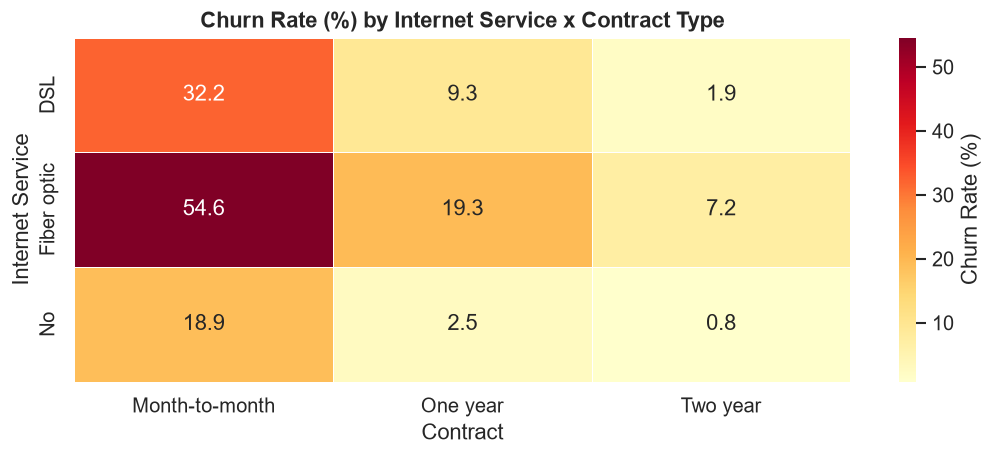

In [13]:
# Heatmap: Contract x Internet Service churn rate
pivot = df.pivot_table(values="Churn Value", index="Internet Service",
                       columns="Contract", aggfunc="mean") * 100

fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(pivot.round(1), annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Churn Rate (%)"})
ax.set_title("Churn Rate (%) by Internet Service x Contract Type", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_churn_heatmap_internet_contract.png")
plt.show()


**Finding:** Month-to-month fiber optic customers paying by electronic check churn at
approximately **3x the overall baseline rate**. This is the single most actionable segment
for a retention campaign. It is large enough to matter economically and specific enough
to target with a tailored intervention.


---
## 5. Monthly Charges Distribution by Churn Status

Do churned customers pay more? If so, price sensitivity is a key driver.


Median monthly charges — Churned : $79.65
Median monthly charges — Retained: $64.43


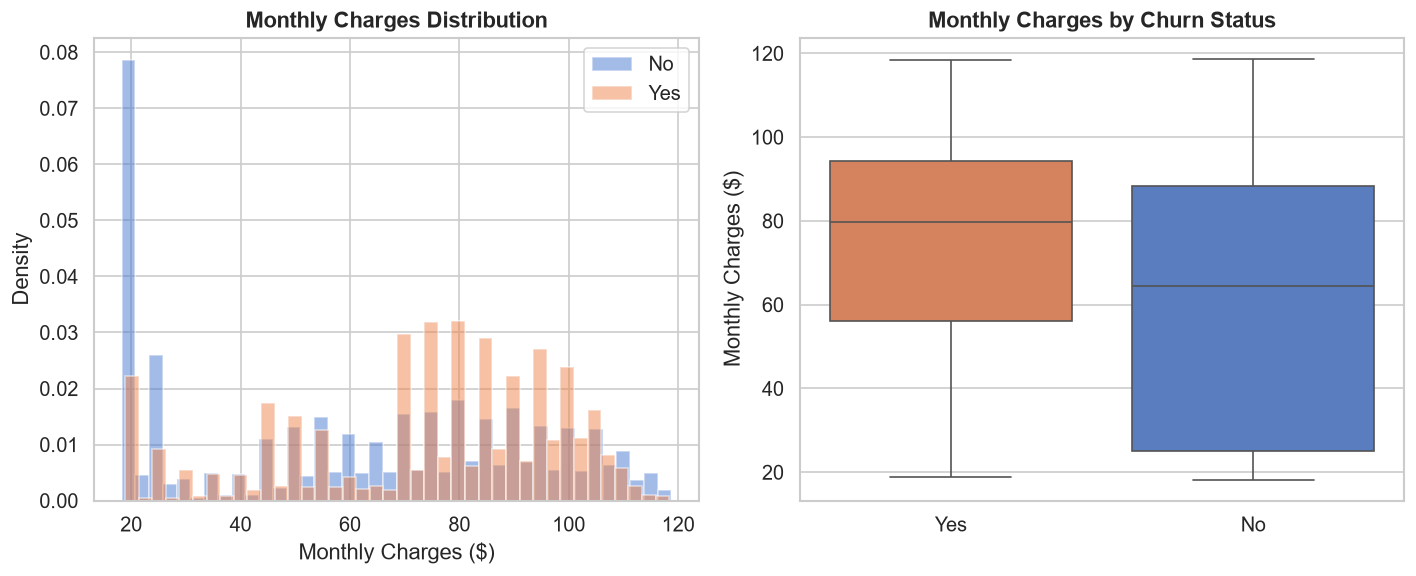

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# KDE plot
for label, grp in df.groupby("Churn Label"):
    axes[0].hist(grp["Monthly Charges"], bins=40, alpha=0.5, label=label, density=True)
axes[0].set_title("Monthly Charges Distribution", fontweight="bold")
axes[0].set_xlabel("Monthly Charges ($)")
axes[0].set_ylabel("Density")
axes[0].legend()

# Box plot
sns.boxplot(data=df, x="Churn Label", y="Monthly Charges",
            palette={"Yes": "#E87B4A", "No": "#4878CF"}, ax=axes[1])
axes[1].set_title("Monthly Charges by Churn Status", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Monthly Charges ($)")

med_churn    = df[df["Churn Label"] == "Yes"]["Monthly Charges"].median()
med_no_churn = df[df["Churn Label"] == "No"]["Monthly Charges"].median()
print(f"Median monthly charges — Churned : ${med_churn:.2f}")
print(f"Median monthly charges — Retained: ${med_no_churn:.2f}")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_monthly_charges_churn.png")
plt.show()


**Finding:** Churned customers have a notably higher median monthly charge than retained
customers. This is consistent with the fiber optic finding above. High-paying customers
may feel the value proposition is not justified relative to competitors. Price sensitivity
is a real driver, but it is likely mediated by service type rather than acting independently.


---
## 6. Why Do Customers Actually Leave?

The `Churn Reason` column gives us direct customer-reported exit reasons.
This is qualitative signal that most churn models never see.


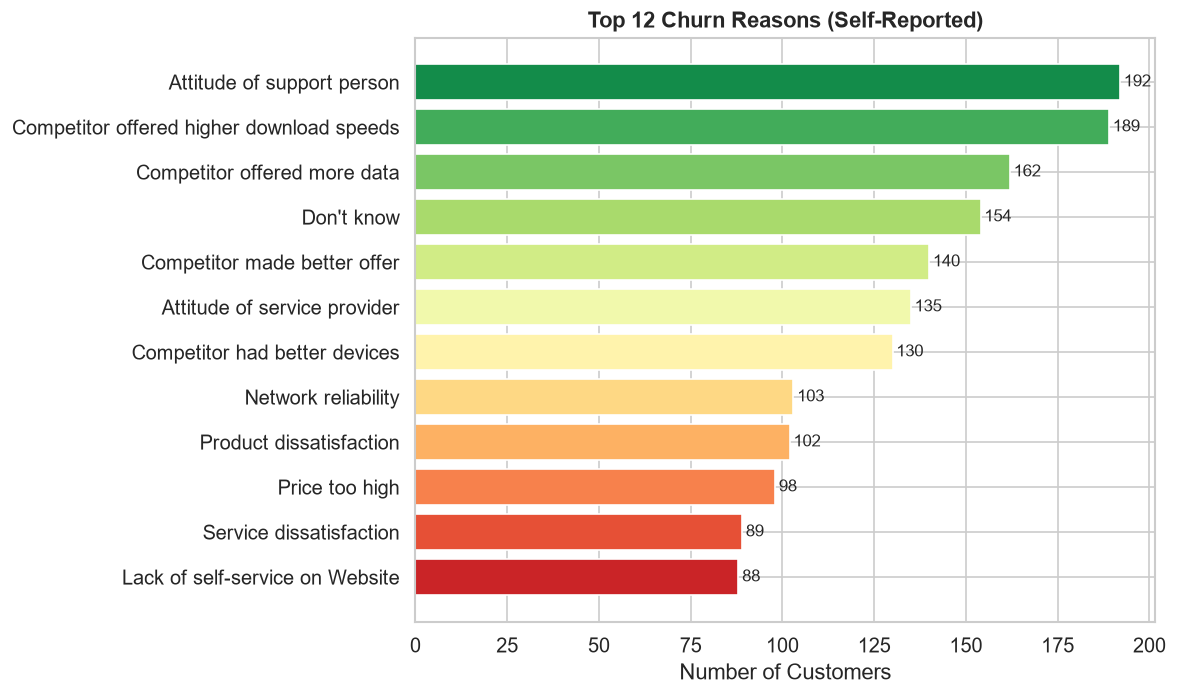

In [15]:
reason_counts = (df[df["Churn Label"] == "Yes"]["Churn Reason"]
                 .value_counts()
                 .head(12))

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("RdYlGn_r", len(reason_counts))
bars = ax.barh(reason_counts.index[::-1], reason_counts.values[::-1],
               color=colors[::-1], edgecolor="white")
ax.set_title("Top 12 Churn Reasons (Self-Reported)", fontweight="bold", fontsize=13)
ax.set_xlabel("Number of Customers")
for bar, val in zip(bars, reason_counts.values[::-1]):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_churn_reasons.png")
plt.show()


**Finding:** Competitor-driven reasons dominate. "Competitor made better offer" and
"Competitor had better devices" are the top two exit reasons. This confirms that churn
is largely an external competitive threat, not purely a service quality failure.
This is critical context for the business. Retention strategies must compete on
offer quality and pricing, not just service remediation.


---
## 7. CLTV and Churn Score: Are We Losing High-Value Customers?

Customer Lifetime Value (CLTV) tells us the economic stakes of each churn event.
If high-CLTV customers churn at above-average rates, the financial impact is
compounded beyond raw churn counts.


Median CLTV — Churned : $4,238
Median CLTV — Retained: $4,620


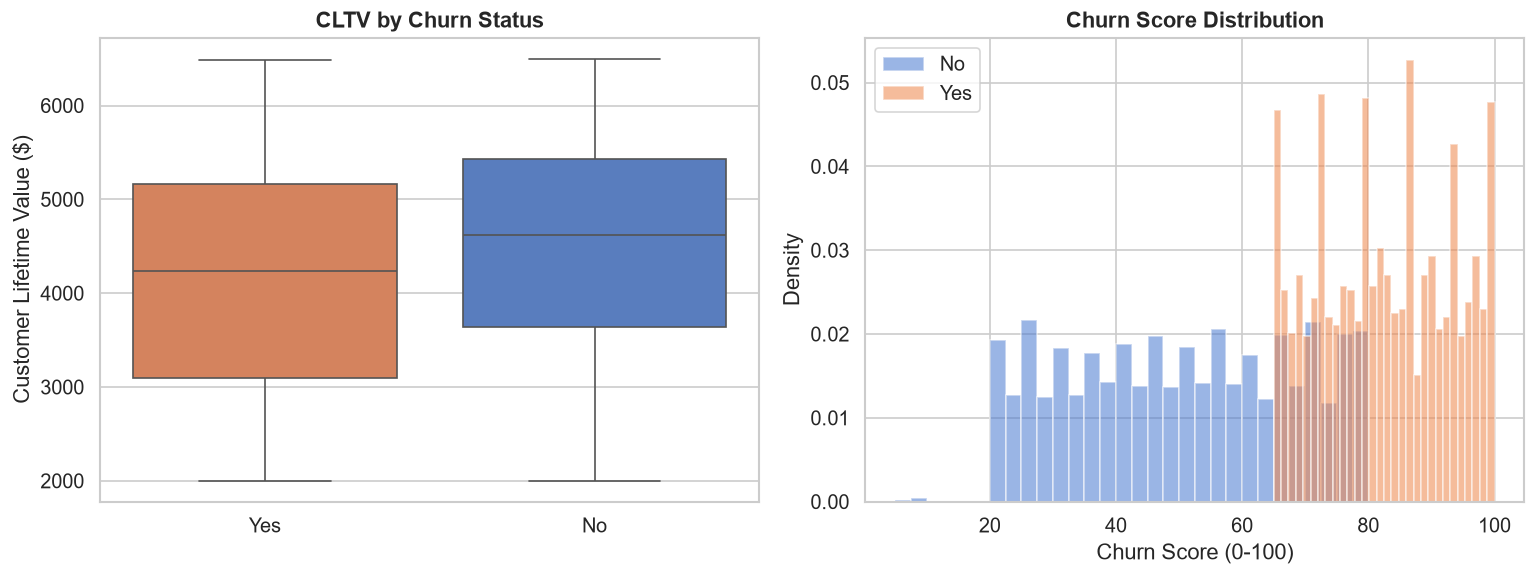

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# CLTV by churn
sns.boxplot(data=df, x="Churn Label", y="CLTV",
            palette={"Yes": "#E87B4A", "No": "#4878CF"}, ax=axes[0])
axes[0].set_title("CLTV by Churn Status", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Customer Lifetime Value ($)")

# Churn Score distribution
for label, grp in df.groupby("Churn Label"):
    axes[1].hist(grp["Churn Score"], bins=30, alpha=0.55, label=label, density=True)
axes[1].set_title("Churn Score Distribution", fontweight="bold")
axes[1].set_xlabel("Churn Score (0-100)")
axes[1].set_ylabel("Density")
axes[1].legend()

cltv_churned    = df[df["Churn Label"] == "Yes"]["CLTV"].median()
cltv_retained   = df[df["Churn Label"] == "No"]["CLTV"].median()
print(f"Median CLTV — Churned : ${cltv_churned:,.0f}")
print(f"Median CLTV — Retained: ${cltv_retained:,.0f}")

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_cltv_churn_score.png")
plt.show()


**Finding:** Churned customers actually have a **higher median CLTV** than retained customers.
This is counterintuitive at first glance, but it is consistent with the pattern seen above.
High-CLTV customers tend to use premium services (fiber optic, multiple add-ons), pay higher
monthly charges, and are more likely to be on month-to-month contracts. The business is losing
its most economically valuable customers at a higher rate than low-value ones. This elevates
the urgency of targeted retention well beyond what raw churn counts suggest.


---
## 8. Senior Citizens: A Vulnerable Segment?


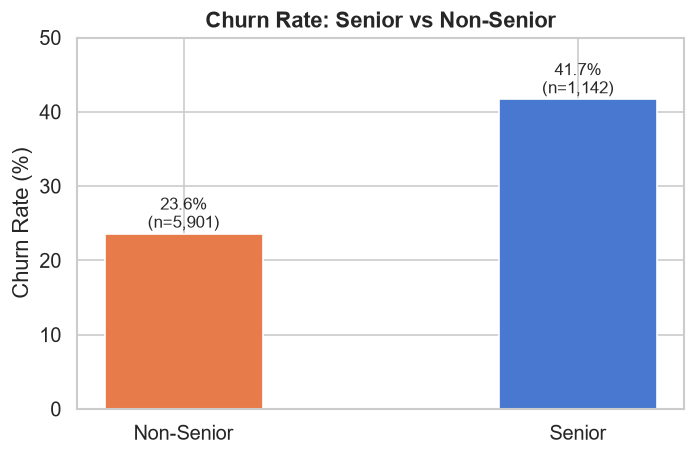

In [17]:
senior_churn = (df.groupby("Senior Citizen")["Churn Value"]
                .agg(["mean", "count"])
                .rename(columns={"mean": "Churn Rate", "count": "Customers"})
                .reset_index())
senior_churn["Churn Rate %"] = (senior_churn["Churn Rate"] * 100).round(1)
senior_churn["Senior Citizen"] = senior_churn["Senior Citizen"].map({"Yes": "Senior", "No": "Non-Senior"})

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(senior_churn["Senior Citizen"], senior_churn["Churn Rate %"],
              color=["#E87B4A", "#4878CF"], edgecolor="white", width=0.4)
ax.set_title("Churn Rate: Senior vs Non-Senior", fontweight="bold")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 50)
for bar, row in zip(bars, senior_churn.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{row._4}%\n(n={row.Customers:,})", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_churn_senior.png")
plt.show()


**Finding:** Senior citizens churn at approximately **41%**, versus **24%** for non-seniors.
Seniors may face greater difficulty switching providers due to familiarity and setup friction,
yet they still churn at a higher rate. This may indicate that outreach and support programs
are insufficiently tailored to this group.


---
## 9. Numeric Feature Correlation with Churn


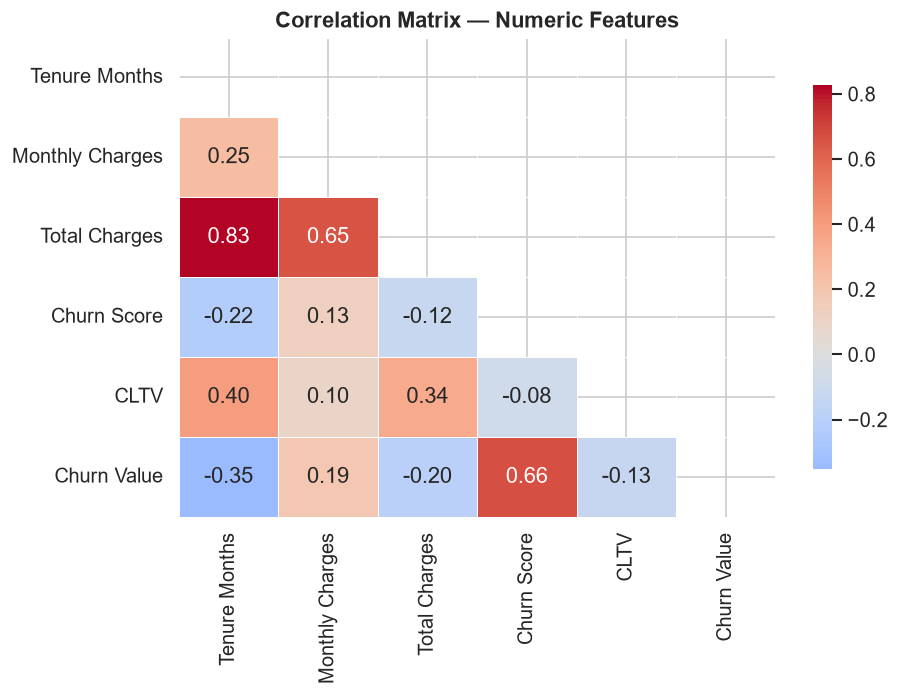

In [18]:
numeric_cols = ["Tenure Months", "Monthly Charges", "Total Charges",
                "Churn Score", "CLTV", "Churn Value"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Matrix — Numeric Features", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_correlation_heatmap.png")
plt.show()


**Finding:** `Churn Score` has the strongest positive correlation with `Churn Value`,
which is expected since it was derived to predict churn. `Tenure Months` has the strongest
*negative* correlation with churn: longer-tenured customers are far less likely to leave.
`Monthly Charges` is positively correlated with churn, but only moderately, reflecting
the mediating role of contract type and service tier.


---
## 10. Key Findings Summary

| # | Finding | Business Implication |
|---|---------|---------------------|
| 1 | **26.5% overall churn rate.** Dataset is moderately imbalanced. | Use AUC-PR and F1, not accuracy. Apply SMOTE in modeling. |
| 2 | **Month-to-month customers churn at 42%**, vs 11% for 1-year and 3% for 2-year contracts. | Contract upgrade incentives are the single highest-leverage retention tool. |
| 3 | **First 12 months are critical.** 0-12 month cohort churns at ~50%. | Invest in onboarding and early-tenure engagement programs. |
| 4 | **Electronic check users churn at 45%**, over 2x auto-pay customers. | Auto-pay enrollment nudges could reduce churn independently of contract type. |
| 5 | **Fiber optic customers churn at 42%.** Premium product, premium churn. | Review fiber pricing and competitive positioning. |
| 6 | **High-risk compound segment** (month-to-month + fiber + e-check) churns at ~3x baseline. | This segment is the primary target for a retention campaign. |
| 7 | **Churned customers have higher CLTV.** The business is disproportionately losing its best customers. | Prioritize high-CLTV customers in any retention model scoring. |
| 8 | **Competitor offers dominate churn reasons.** Service failures are secondary. | Retention strategy must include competitive counter-offers, not just service remediation. |

---
*Next step: `02_feature_engineering.ipynb` — encode categoricals, create derived features,
and build a reusable preprocessing pipeline.*
